## MAN TruckScenes: metadata and condition analysis

**Purpose of this notebook:** analyse the condition distribution across train/val splits and create a stratified holdout evaluation set from training data.

**Why the need:**
1. The official validation split has 0-1 scenes for snow, fog, tunnel, residential, which is too few for reliable per-condition evaluation
2. The official test set has no public annotations. The dataset authors state in the download page: 'For the test set, there's no public ground truth' (evaluation is only possible via their HuggingFace challenge). This was also confirmed empirically: `sample_annotation.json` in the test metadata contains 0 annotations (confirmed in downloading_pipeline.ipynb, https://colab.research.google.com/drive/1xy24GaGdtLqSBDDQQ_JeIlSPsW_S8L9d?usp=drive_link).
3. Using validation for both early stopping and final evaluation introduces bias

**Input:** `metadata_train.csv` and `metadata_val.csv` from the YOLO export pipeline (https://colab.research.google.com/drive/1XYNh7BnS3jBlvpcFFOsQnTTfHe3Nf0YH?usp=drive_link)

**The outputs cover**
- Condition distribution tables (per split, cross-condition, per-class)
- Camera position analysis (box density by camera and condition)
- A stratified holdout split (79 scenes from train), seeded to guarantee rare condition representation and checked for per-class balance → **saved as `truckscenes_yolo/holdout_split.json`**

**Note on the official split:** the authors mention in their study that they used a Pareto-optimal multi-objective optimisation to balance condition characteristics across train/val/test. Despite this, rare conditions like fog (1 val scene) and snow (1 val scene) are simply too scarce in the dataset for the 75-scene val split to cover adequately. Since test is unavailable, evaluation falls entirely on val, which the optimisation was not designed for.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import json
import os
from collections import Counter

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/truckscenes_yolo/metadata_train.csv")
val = pd.read_csv("/content/drive/MyDrive/truckscenes_yolo/metadata_val.csv")

In [ ]:
TAG_COLS = ["tag_weather", "tag_area", "tag_daytime", "tag_season", "tag_lighting", "tag_structure", "tag_construction"]

# condition distr per split
print("Samples per condition value:\n")
for col in TAG_COLS:
    print(f"{col}:")
    combined = pd.DataFrame({
        "train": train[col].value_counts(),
        "val": val[col].value_counts()
    }).fillna(0).astype(int)
    combined["total"] = combined.sum(axis=1)
    combined = combined.sort_values("total", ascending=False)
    print(combined)
    print()

# scene counts (not image counts) per condition
print("\nScenes per condition value:\n")
for col in TAG_COLS:
    print(f"{col}:")
    combined = pd.DataFrame({
        "train": train.groupby(col)["scene_token"].nunique(),
        "val": val.groupby(col)["scene_token"].nunique()
    }).fillna(0).astype(int)
    combined["total"] = combined.sum(axis=1)
    combined = combined.sort_values("total", ascending=False)
    print(combined)
    print()

Samples per condition value:

tag_weather:
               train   val  total
tag_weather                      
clear          35972  6240  42212
overcast       24800  3660  28460
rain           17436  1600  19036
snow            3520   160   3680
fog             1740   160   1900
other_weather    160   160    320

tag_area:
             train   val  total
tag_area                       
highway      62672  7840  70512
terminal      7360  1280   8640
rural         7040  1260   8300
city          4316  1280   5596
residential   1760   160   1920
parking        480     0    480
other_area       0   160    160

tag_daytime:
             train   val  total
tag_daytime                    
noon         44956  6060  51016
morning      32432  4000  36432
evening       6240  1920   8160

tag_season:
            train   val  total
tag_season                    
summer      39972  3520  43492
autumn      30536  5440  35976
winter      13120  3020  16140

tag_lighting:
                train   val  

### Condition distribution per split and scene counts per condition

The main issues appear in the validation split, it has severe imbalances:

- snow: 1 val scene (160 images) -> too few for reliable mAP
- fog: 1 val scene (160 images) -> same problem
- residential: 1 val scene (160 images)
- tunnel: 1 val scene (160 images)
- parking: 0 val scenes -> completely missing
- other_weather and other_area: 1 scene each, basically noise

Clear, overcast, rain is reasonably covered, there are enough scenes for meaningful comparison. Highway, terminal, rural, city is also workable.

Note: looking at this output alone, we CANNOT take validation set for evaluation, it is too sparse for certain conditions.

In [ ]:
# cross tabulation: weather + daytime (scenes)
print("Weather + daytime (scene counts, train+val combined):\n")
combined = pd.concat([train, val])
cross = combined.groupby(["tag_weather", "tag_daytime"])["scene_token"].nunique().unstack(fill_value=0)
print(cross)

# cross tabulation: weather + lighting
print("\nWeather + lighting (scene counts):\n")
cross2 = combined.groupby(["tag_weather", "tag_lighting"])["scene_token"].nunique().unstack(fill_value=0)
print(cross2)

# per-class box counts by weather (using num_boxes is aggregate,
# but we can at least see total boxes per condition)
print("\nMean boxes per image by weather:\n")
print(combined.groupby("tag_weather")["num_boxes"].mean().round(1))

print("\nMean boxes per image by daytime:\n")
print(combined.groupby("tag_daytime")["num_boxes"].mean().round(1))

print("\nMean boxes per image by area:\n")
print(combined.groupby("tag_area")["num_boxes"].mean().round(1))

Weather + daytime (scene counts, train+val combined):

tag_daytime    evening  morning  noon
tag_weather                          
clear               47      111   106
fog                  0       12     0
other_weather        0        1     1
overcast             0       76   102
rain                 4       28    87
snow                 0        0    23

Weather + lighting (scene counts):

tag_lighting   dark  glare  illuminated  other_lighting  twilight
tag_weather                                                      
clear            33      0          187               2        42
fog               0      0           12               0         0
other_weather     0      0            1               0         1
overcast          0      0          178               0         0
rain              5     34           79               0         1
snow              0      0           23               0         0

Mean boxes per image by weather:

tag_weather
clear            10.3
fog    

### Cross-condition findings

- Weather and daytime are not independent. Fog only appears in morning scenes (12 scenes), never at noon or evening (makes sense, even though fog technically can appear anytime when the right conditions met but it is most often in the morning). Snow only appears at noon (23 scenes). This means the dataset cannot support evaluation of fog (rare case anyway) or snow (more significant) under different times of day.

- Glare is fully confounded with rain. All 34 glare scenes are rain scenes. Glare cannot be treated as an independent lighting condition.

- Dark scenes are mostly clear weather. 33 of 38 dark scenes are clear, with only 5 in rain. No dark scenes exist for fog, snow or overcast. This limits the ability to evaluate night driving under adverse weather.

- Annotation density varies substantially by area. City scenes average 23.5 boxes per image compared to 6.4 in terminal scenes. When comparing per-area detection performance, this difference should be accounted for, as lower mAP in sparse scenes may reflect fewer objects rather than worse detection.

- Weather has a moderate effect on annotation density. Overcast and rain scenes average 13+ boxes/image, while snow (7.9) and fog (8.7) are sparser. This could partly reflect the environments where these conditions were recorded rather than weather itself.

In [ ]:
# note: since there are no annotations for the test set (verified in the downloading_pipeline.ipynb notebook)
# idea/suggested approach is to take a held-out set from the training data

# check: how many scenes in train to work with for holding out
train_scenes = train.groupby("scene_token").first()[TAG_COLS]
print(f"total train scenes: {len(train_scenes)}\n")

# say, we hold out 15% of train scenes for evaluation
n_holdout = int(len(train_scenes) * 0.15)
print(f"holdout: {n_holdout} scenes\n")

# check: if we can afford to hold out and still keep
# reasonable counts for rare conditions in the remaining train set
print("train scene counts per condition (pre-holdout):\n")
for col in ["tag_weather", "tag_daytime", "tag_area", "tag_lighting"]:
    print(f"{col}:")
    print(train_scenes[col].value_counts())
    print()

total train scenes: 523

holdout: 78 scenes

train scene counts per condition (pre-holdout):

tag_weather:
tag_weather
clear            225
overcast         155
rain             109
snow              22
fog               11
other_weather      1
Name: count, dtype: int64

tag_daytime:
tag_daytime
noon       281
morning    203
evening     39
Name: count, dtype: int64

tag_area:
tag_area
highway        392
terminal        46
rural           44
city            27
residential     11
parking          3
Name: count, dtype: int64

tag_lighting:
tag_lighting
illuminated       431
twilight           33
dark               29
glare              29
other_lighting      1
Name: count, dtype: int64



### Regarding holdout feasibility

With 523 train scenes, a 15% holdout gives 78 scenes for a dedicated evaluation set. The main constraint is rare conditions: fog (11 scenes), residential (11), tunnel (9) and parking (3) have very few scenes to begin with.

Most rare conditions can spare 1-4 scenes for a holdout while keeping enough for training. The exception is parking (3 scenes), which cannot be held out at all. other_weather and other_lighting (1 scene each) are excluded from the analysis entirely.

The holdout is stratified: rare conditions are seeded first to guarantee representation, then the remaining slots are filled randomly from common conditions.

In [ ]:
SEED = 123
np.random.seed(SEED)

# per-scene condition tags (one row per scene)
train_scenes = train.groupby("scene_token").first()[TAG_COLS + ["scene_name"]].copy()
print(f"Total train scenes: {len(train_scenes)}\n")

# holdout fractions for rare vs common conditions
HOLDOUT_FRAC = 0.15
N_HOLDOUT = int(len(train_scenes) * HOLDOUT_FRAC)

# strategy: first make sure rare conditions get representation in holdout,
# then fill the rest randomly from remaining scenes

# identify scenes by rare conditions that must be in holdout
rare_conditions = {
    "tag_weather": ["fog", "snow"],
    "tag_area": ["residential"],
    "tag_lighting": ["dark", "glare", "twilight"],
    "tag_structure": ["tunnel"],
    "tag_daytime": ["evening"],
}

# for each rare condition, hold out a fixed no. of scenes
holdout_tokens = set()

for col, values in rare_conditions.items():
    for val in values:
        eligible = sorted(train_scenes[train_scenes[col] == val].index.tolist())
        # hold out 20% of scenes for this condition, minimum 1
        n = max(1, int(len(eligible) * 0.20))
        chosen = np.random.choice(eligible, size=min(n, len(eligible)), replace=False)
        holdout_tokens.update(chosen)
        print(f"{col}={val}: {len(eligible)} scenes, holding out {len(chosen)}")

print(f"\nAfter rare-condition seeding: {len(holdout_tokens)} holdout scenes")

# fill remaining holdout slots randomly from scenes not yet selected
remaining = sorted([t for t in train_scenes.index if t not in holdout_tokens])
n_remaining = N_HOLDOUT - len(holdout_tokens)

if n_remaining > 0:
    extra = np.random.choice(remaining, size=n_remaining, replace=False)
    holdout_tokens.update(extra)
    print(f"Added {len(extra)} random scenes, total holdout: {len(holdout_tokens)}")

# split
holdout_tokens = list(holdout_tokens)
train_keep = train_scenes.drop(holdout_tokens)
train_holdout = train_scenes.loc[holdout_tokens]

print(f"\nFinal split: {len(train_keep)} train / {len(train_holdout)} holdout")

Total train scenes: 523

tag_weather=fog: 11 scenes, holding out 2
tag_weather=snow: 22 scenes, holding out 4
tag_area=residential: 11 scenes, holding out 2
tag_lighting=dark: 29 scenes, holding out 5
tag_lighting=glare: 29 scenes, holding out 5
tag_lighting=twilight: 33 scenes, holding out 6
tag_structure=tunnel: 9 scenes, holding out 1
tag_daytime=evening: 39 scenes, holding out 7

After rare-condition seeding: 31 holdout scenes
Added 47 random scenes, total holdout: 78

Final split: 445 train / 78 holdout


In [ ]:
print("condition coverage (holdout):\n")
for col in ["tag_weather", "tag_daytime", "tag_area", "tag_lighting", "tag_structure"]:
    print(f"{col}:")
    coverage = pd.DataFrame({
        "train_keep": train_keep[col].value_counts(),
        "holdout": train_holdout[col].value_counts()
    }).fillna(0).astype(int)
    coverage = coverage.sort_values("train_keep", ascending=False)
    print(coverage)
    print()

condition coverage (holdout):

tag_weather:
               train_keep  holdout
tag_weather                       
clear                 185       40
overcast              143       12
rain                   94       15
snow                   15        7
fog                     7        4
other_weather           1        0

tag_daytime:
             train_keep  holdout
tag_daytime                     
noon                240       41
morning             180       23
evening              25       14

tag_area:
             train_keep  holdout
tag_area                        
highway             336       56
terminal             40        6
rural                40        4
city                 19        8
residential           7        4
parking               3        0

tag_lighting:
                train_keep  holdout
tag_lighting                       
illuminated            385       46
glare                   21        8
twilight                20       13
dark                    18 

### Holdout coverage verification

All targeted rare conditions are represented in the holdout: fog (4 scenes), snow (7), dark (11), glare (8), twilight (13), tunnel (2), residential (4), evening (14). This is a significant improvement over the official val split, which had 0-1 scenes for most of these.

The impact on the training set: fog drops to 7 scenes and tunnel to 7 after holdout. This is thin for training but acceptable for a stress-testing project. Limited training exposure to these conditions is itself part of the analysis, as we are measuring how the model handles conditions it has seen rarely.

Conditions excluded from evaluation: parking (0 holdout scenes, only 3 in dataset), other_weather (1 scene total), other_lighting (1 scene total).

In [ ]:
# split train images into keep and holdout
train_holdout_imgs = train[train["scene_token"].isin(holdout_tokens)]
train_keep_imgs = train[~train["scene_token"].isin(holdout_tokens)]

print(f"train keep images: {len(train_keep_imgs)}")
print(f"holdout images: {len(train_holdout_imgs)}\n")

print("Holdout image counts per condition:\n")
for col in ["tag_weather", "tag_daytime", "tag_area", "tag_lighting"]:
    print(f"{col}:")
    coverage = pd.DataFrame({
        "train_keep": train_keep_imgs[col].value_counts(),
        "holdout": train_holdout_imgs[col].value_counts()
    }).fillna(0).astype(int)
    coverage = coverage.sort_values("train_keep", ascending=False)
    print(coverage)
    print()

train keep images: 71172
holdout images: 12456

Holdout image counts per condition:

tag_weather:
               train_keep  holdout
tag_weather                       
clear               29572     6400
overcast            22880     1920
rain                15040     2396
snow                 2400     1120
fog                  1120      620
other_weather         160        0

tag_daytime:
             train_keep  holdout
tag_daytime                     
noon              38400     6556
morning           28772     3660
evening            4000     2240

tag_area:
             train_keep  holdout
tag_area                        
highway           53732     8940
terminal           6400      960
rural              6400      640
city               3040     1276
residential        1120      640
parking             480        0

tag_lighting:
                train_keep  holdout
tag_lighting                       
illuminated          61572     7340
glare                 3360     1276
twilight 

In [ ]:
# additionally: camera position check
print("Mean boxes per image by camera:\n")
print(combined.groupby("cam_key")["num_boxes"].mean().round(1))

print("\nMean boxes per image: camera + weather:\n")
print(combined.groupby(["cam_key", "tag_weather"])["num_boxes"].mean().round(1).unstack())

Mean boxes per image by camera:

cam_key
CAMERA_LEFT_BACK      11.6
CAMERA_LEFT_FRONT     14.9
CAMERA_RIGHT_BACK      5.4
CAMERA_RIGHT_FRONT    14.6
Name: num_boxes, dtype: float64

Mean boxes per image: camera + weather:

tag_weather         clear   fog  other_weather  overcast  rain  snow
cam_key                                                             
CAMERA_LEFT_BACK     10.7   9.6            8.6      13.1  12.4   7.7
CAMERA_LEFT_FRONT    13.0  11.5           10.1      16.8  17.4  10.5
CAMERA_RIGHT_BACK     4.9   2.6            4.3       6.5   5.6   3.4
CAMERA_RIGHT_FRONT   12.7  11.2            9.9      16.6  17.0  10.1


### Camera position analysis

RIGHT_BACK consistently has the lowest annotation density across all conditions (5.4 boxes/image vs 11.6 - 14.9 for all other positions). This likely reflects two factors: trailer occlusion (the right back camera faces the trailer body) and right-hand traffic.Front cameras (LEFT_FRONT at 14.9, RIGHT_FRONT at 14.6) capture the most objects. LEFT_BACK (11.6) sits between front and right back, as it faces adjacent lanes and oncoming traffic.

This pattern holds across all weather conditions, suggesting it is structural (camera placement and traffic side) rather than condition-dependent. Per-camera mAP comparisons should account for this density difference.

In [ ]:
label_dir = "/content/drive/MyDrive/truckscenes_yolo"
print(os.listdir(label_dir))

['metadata_train.csv', 'metadata_val.csv', 'truckscenes_yolo_4cam_train_val.zip', 'truckscenes_4cam.yaml', 'runs', 'holdout_split.json']


In [ ]:
!unzip -q "/content/drive/MyDrive/truckscenes_yolo/truckscenes_yolo_4cam_train_val.zip" \
  "truckscenes_yolo/labels/*" -d /content/

In [ ]:
!ls /content/truckscenes_yolo/labels/
!ls /content/truckscenes_yolo/labels/train/ | head -5

train  val
0000e8e72c3e449ca86fd3fd4f64b733_CAMERA_LEFT_BACK.txt
0000e8e72c3e449ca86fd3fd4f64b733_CAMERA_LEFT_FRONT.txt
0000e8e72c3e449ca86fd3fd4f64b733_CAMERA_RIGHT_BACK.txt
0000e8e72c3e449ca86fd3fd4f64b733_CAMERA_RIGHT_FRONT.txt
0000f18d31ae472c966bd09267875b9d_CAMERA_LEFT_BACK.txt


In [ ]:
CLASS_NAMES = ["car", "truck", "bus", "trailer", "other_vehicle", "pedestrian",
               "motorcycle", "bicycle", "traffic_cone", "barrier", "animal", "traffic_sign"]

def count_classes_in_label(label_path):
    counts = Counter()
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                counts[int(parts[0])] += 1
    return counts

# parse all train labels
label_dir = "/content/truckscenes_yolo/labels/train"
rows = []
for _, row in train.iterrows():
    label_path = os.path.join(label_dir, row["image_name"].rsplit(".", 1)[0] + ".txt")
    if os.path.exists(label_path):
        counts = count_classes_in_label(label_path)
        for cid, count in counts.items():
            rows.append({
                "scene_token": row["scene_token"],
                "tag_weather": row["tag_weather"],
                "tag_area": row["tag_area"],
                "tag_daytime": row["tag_daytime"],
                "cam_key": row["cam_key"],
                "class_id": cid,
                "class_name": CLASS_NAMES[cid],
                "count": count,
            })

class_df = pd.DataFrame(rows)
print(f"Parsed {len(class_df)} class-level entries\n")

# class distr by weather
print("Boxes per class by weather:\n")
print(class_df.groupby(["tag_weather", "class_name"])["count"].sum().unstack(fill_value=0))

Parsed 240889 class-level entries

Boxes per class by weather:

class_name     animal  barrier  bicycle   bus     car  motorcycle  \
tag_weather                                                         
clear             713     1029      826   487  173662        1189   
fog               236        0        0     0    7862           0   
other_weather       0        0        0     0     351           0   
overcast          264      616      592  1539  146970         340   
rain                0      700      115   808  120613         267   
snow                0       35      101   462   14092           0   

class_name     other_vehicle  pedestrian  traffic_cone  traffic_sign  trailer  \
tag_weather                                                                     
clear                   2864        7575         10542         74287    34645   
fog                        0           0          1853          2373      515   
other_weather              0           0             0     

In [ ]:
# class distr by weather (percentage within each weather)
print("class distribution by weather (% of boxes):\n")
weather_class = class_df.groupby(["tag_weather", "class_name"])["count"].sum().unstack(fill_value=0)
weather_pct = weather_class.div(weather_class.sum(axis=1), axis=0).mul(100).round(1)
print(weather_pct[["car", "truck", "trailer", "traffic_sign", "pedestrian", "traffic_cone", "bus"]])

# class distr by area
print("\nclass distribution by area (% of boxes):\n")
area_class = class_df.groupby(["tag_area", "class_name"])["count"].sum().unstack(fill_value=0)
area_pct = area_class.div(area_class.sum(axis=1), axis=0).mul(100).round(1)
print(area_pct[["car", "truck", "trailer", "traffic_sign", "pedestrian", "traffic_cone", "bus"]])

# pedestrians by area (absolute counts)
print("\nPedestrian boxes by area and daytime:\n")
ped = class_df[class_df["class_name"] == "pedestrian"]
print(ped.groupby(["tag_area", "tag_daytime"])["count"].sum().unstack(fill_value=0))

class distribution by weather (% of boxes):

class_name      car  truck  trailer  traffic_sign  pedestrian  traffic_cone  \
tag_weather                                                                   
clear          47.4   15.9      9.5          20.3         2.1           2.9   
fog            56.2    8.2      3.7          17.0         0.0          13.2   
other_weather  48.1    0.0      0.0          51.9         0.0           0.0   
overcast       46.2   13.9      7.3          24.4         1.3           5.0   
rain           53.6   16.1      6.4          21.0         0.9           0.8   
snow           50.2   13.0      5.9          23.9         2.0           2.1   

class_name     bus  
tag_weather         
clear          0.1  
fog            0.0  
other_weather  0.0  
overcast       0.5  
rain           0.4  
snow           1.6  

class distribution by area (% of boxes):

class_name    car  truck  trailer  traffic_sign  pedestrian  traffic_cone  bus
tag_area                        

### Per-class distribution by condition

Insights based on the output above:

- Weather has minimal effect on class composition. Cars dominate across all weather conditions (46-56%), followed by traffic signs (17-24%) and trucks (8-16%). The relative class distribution is actually very stable across weather, meaning condition-stratified mAP differences are unlikely to be caused by class mix shifts. **Important/notable exceptions:** fog has zero pedestrians, zero bicycles and zero motorcycles in the training set. Any detection of these classes in fog scenes would be entirely unsupported by training data.

- Area has a strong effect on class composition. Terminal scenes are dominated by trucks (30.9%) and trailers (30.2%) with very few cars (15.8%), while city and highway scenes are car-dominated (51-52%). Pedestrians are concentrated in city (7.3%) and terminal (9.1%) scenes and nearly absent from highway (0.2%) and rural (0.4%). All make sense logically. Still, this has *some implications*: per-class mAP by area will partly reflect class prevalence, not just detection difficulty. A model failing to detect pedestrians on highways may simply have almost no highway pedestrian training data.

- Pedestrians are heavily skewed by area and time. City-noon accounts for the majority of pedestrian annotations (5,888 boxes). Terminal-morning and terminal-noon also contribute substantially. Evening pedestrians exist almost exclusively in city scenes (887 boxes). No pedestrian annotations exist for parking-evening, residential-evening or rural-evening.

In [ ]:
# additional check: verify the holdout does not accidentally introduce a class imbalance in the remaining training set
# compare total box counts per class: full train vs train_keep
label_dir = "/content/truckscenes_yolo/labels/train"

keep_tokens = set(train_keep_imgs["scene_token"])
holdout_tokens_set = set(holdout_tokens)

keep_counts = Counter()
holdout_counts = Counter()

for _, row in train.iterrows():
    label_path = os.path.join(label_dir, row["image_name"].rsplit(".", 1)[0] + ".txt")
    if not os.path.exists(label_path):
        continue
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cid = int(parts[0])
                if row["scene_token"] in holdout_tokens_set:
                    holdout_counts[cid] += 1
                else:
                    keep_counts[cid] += 1

print("class boxes: train_keep vs holdout\n")
for cid in range(len(CLASS_NAMES)):
    k = keep_counts[cid]
    h = holdout_counts[cid]
    total = k + h
    pct = h / total * 100 if total > 0 else 0
    print(f"  {CLASS_NAMES[cid]:15s}  keep={k:>7d}  holdout={h:>6d}  holdout%={pct:.1f}%")

class boxes: train_keep vs holdout

  car              keep= 387183  holdout= 76367  holdout%=16.5%
  truck            keep= 122558  holdout= 20788  holdout%=14.5%
  bus              keep=   2425  holdout=   871  holdout%=26.4%
  trailer          keep=  65520  holdout=  9037  holdout%=12.1%
  other_vehicle    keep=   5986  holdout=   495  holdout%=7.6%
  pedestrian       keep=  11605  holdout=  2628  holdout%=18.5%
  motorcycle       keep=   1478  holdout=   318  holdout%=17.7%
  bicycle          keep=   1007  holdout=   627  holdout%=38.4%
  traffic_cone     keep=  24105  holdout=  6488  holdout%=21.2%
  barrier          keep=   2045  holdout=   335  holdout%=14.1%
  animal           keep=   1213  holdout=     0  holdout%=0.0%
  traffic_sign     keep= 174768  holdout= 33829  holdout%=16.2%


### Class balance in holdout

Most classes are close to the target 15% holdout fraction. Two exceptions: bicycle (38.4% in holdout, only 1,634 total boxes) and animal (0% in holdout, only 1,213 total boxes). Both are extremely sparse classes where a few scenes account for most annotations. Bus (26.4%) and other_vehicle (7.6%) show moderate skew.

This means bicycle detection performance may be slightly overestimated (more evaluation data) while animal detection cannot be evaluated on the holdout set.

In [ ]:
# check: which scenes have bicycle and animal boxes
bike = class_df[class_df["class_name"] == "bicycle"]
animal = class_df[class_df["class_name"] == "animal"]

print("Bicycle: boxes per scene (top 10):\n")
bike_by_scene = bike.groupby("scene_token")["count"].sum().sort_values(ascending=False)
print(bike_by_scene.head(10))
print(f"\nTotal scenes with bicycles: {len(bike_by_scene)}")
print(f"In holdout: {bike_by_scene.index.isin(holdout_tokens).sum()}")
print(f"In train_keep: {(~bike_by_scene.index.isin(holdout_tokens)).sum()}")

print("\nAnimal: boxes per scene (top 10):\n")
animal_by_scene = animal.groupby("scene_token")["count"].sum().sort_values(ascending=False)
print(animal_by_scene.head(10))
print(f"\nTotal scenes with animals: {len(animal_by_scene)}")
print(f"In holdout: {animal_by_scene.index.isin(holdout_tokens).sum()}")
print(f"In train_keep: {(~animal_by_scene.index.isin(holdout_tokens)).sum()}")

Bicycle: boxes per scene (top 10):

scene_token
e186bb7e51eb4b8e977115478de21987    438
89bf298f53ae4cf3a909e1374b4f32c7    213
1e4dff2793b1442ea144b32d093e4b84    138
c31c14c89d304ee3964e25c216c2255a    115
d0b02e67e97a435192bf43f7bb0f902c    101
b3c174ff1b77480cb4a558681597d47e     99
a04e6d2081e24f06949c024af5af2720     72
ce9d62c78a3540e29df148d14cc6135d     69
38d4ba33fce94499be34f32d245113ed     53
eaba4b4e0dc445e09b7af2cfa2d79247     45
Name: count, dtype: int64

Total scenes with bicycles: 25
In holdout: 4
In train_keep: 21

Animal: boxes per scene (top 10):

scene_token
30cddafdd4b24767a95aac20383d152c    261
1375e471a4e2425e804bcaf6e54bde5e    236
10d746cb037c4ee6a697e6fab327548f    229
0e7e448172154d07918c24cb9c2a6761    160
6b7c308d77c04c6fb4862840a121bcd6    159
5ae6e5f9eb7742c587973e73219ac9f3     64
81f0a41d0a7a44e0ae8f8ea0ade95fdf     37
7dedbc9d6739401387b9811ab9e9d44a     37
9788c0b927c749b389c025c9e767d99c     26
2fb0ce9621ef404cba4fe85e3ccb6bf7      4
Name: count, d

In [ ]:
# proposed fix 1: move 1-2 animal scenes into holdout, swap out same-condition scenes
# pick the smallest animal scenes to minimise training loss
animal_scenes_to_add = animal_by_scene.tail(2).index.tolist()  # smallest animal scenes

# what conditions are these
for t in animal_scenes_to_add:
    row = train_scenes.loc[t]
    print(f"Animal scene {t[:8]}...: weather={row.tag_weather}, area={row.tag_area}, daytime={row.tag_daytime}")

# fix 2: swap some bicycle-heavy holdout scenes back to train
# which holdout scenes have the most bicycles
bike_in_holdout = bike_by_scene[bike_by_scene.index.isin(holdout_tokens)].sort_values(ascending=False)
print(f"\nBicycle scenes in holdout:")
print(bike_in_holdout)

Animal scene 9788c0b9...: weather=overcast, area=highway, daytime=noon
Animal scene 2fb0ce96...: weather=overcast, area=residential, daytime=noon

Bicycle scenes in holdout:
scene_token
e186bb7e51eb4b8e977115478de21987    438
d0b02e67e97a435192bf43f7bb0f902c    101
ce9d62c78a3540e29df148d14cc6135d     69
a79418333e2a4a28a26518df2fb24c65     19
Name: count, dtype: int64


In [ ]:
# The top bicycle holdout scene has 438 boxes, this is the single biggest bicycle scene in the entire dataset.
#Swapping just that one back to training would drop bicycle holdout from 38.4% to approx 11.5%, much closer to target.
# For animals, the two smallest scenes (26 and 4 boxes) are both overcast/noon. Common conditions, easy to swap

# swap: remove the biggest bicycle scene from holdout, add 2 small animal scenes
swap_out = ["e186bb7e51eb4b8e977115478de21987"]  # biggest bike scene, back to train
swap_in = animal_scenes_to_add  # 2 small animal scenes into holdout

holdout_tokens = [t for t in holdout_tokens if t not in swap_out]
holdout_tokens.extend(swap_in)

# net change: removed 1, added 2, holdout is 79 scenes
print(f"Holdout scenes after swap: {len(holdout_tokens)}") # to verify, just in case

# recompute class balance
keep_tokens_set = set(t for t in train_scenes.index if t not in holdout_tokens)
holdout_tokens_set = set(holdout_tokens)

keep_counts = Counter()
holdout_counts = Counter()

for _, row in train.iterrows():
    label_path = os.path.join(label_dir, row["image_name"].rsplit(".", 1)[0] + ".txt")
    if not os.path.exists(label_path):
        continue
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cid = int(parts[0])
                if row["scene_token"] in holdout_tokens_set:
                    holdout_counts[cid] += 1
                else:
                    keep_counts[cid] += 1

print("\nclass boxes after swap:\n")
for cid in range(len(CLASS_NAMES)):
    k = keep_counts[cid]
    h = holdout_counts[cid]
    total = k + h
    pct = h / total * 100 if total > 0 else 0
    print(f"  {CLASS_NAMES[cid]:15s}  keep={k:>7d}  holdout={h:>6d}  holdout%={pct:.1f}%")

Holdout scenes after swap: 79

class boxes after swap:

  car              keep= 387403  holdout= 76147  holdout%=16.4%
  truck            keep= 122257  holdout= 21089  holdout%=14.7%
  bus              keep=   2419  holdout=   877  holdout%=26.6%
  trailer          keep=  65233  holdout=  9324  holdout%=12.5%
  other_vehicle    keep=   5952  holdout=   529  holdout%=8.2%
  pedestrian       keep=  11979  holdout=  2254  holdout%=15.8%
  motorcycle       keep=   1478  holdout=   318  holdout%=17.7%
  bicycle          keep=   1445  holdout=   189  holdout%=11.6%
  traffic_cone     keep=  24113  holdout=  6480  holdout%=21.2%
  barrier          keep=   2056  holdout=   324  holdout%=13.6%
  animal           keep=   1183  holdout=    30  holdout%=2.5%
  traffic_sign     keep= 173830  holdout= 34767  holdout%=16.7%


### Class balance in holdout (after swapping)

After a targeted swap (moving the largest bicycle scene back to training, adding two small animal scenes to holdout), most classes fall within a reasonable range of the target 15% holdout fraction.

Remaining skews: bus (26.6%) and traffic_cone (21.2%) are slightly overrepresented in holdout. Animal (2.5%, only 30 holdout boxes) and other_vehicle (8.2%) are underrepresented. These reflect the inherent sparsity of rare classes concentrated in a few scenes.

Classes with reliable holdout evaluation (within 10-20%): car, truck, trailer, pedestrian, motorcycle, bicycle, barrier, traffic_sign.

In [ ]:
# save the holdout scene tokens for the training
holdout_data = {
    "holdout_scene_tokens": sorted(holdout_tokens),
    "n_train_keep": len(train_scenes) - len(holdout_tokens),
    "n_holdout": len(holdout_tokens),
    "seed": SEED,
}

out_path = "/content/drive/MyDrive/truckscenes_yolo/holdout_split.json"
with open(out_path, "w") as f:
    json.dump(holdout_data, f, indent=2)

**note on what to do with the output:** the training notebook should load those tokens (identifiers), filter out the holdout scenes from train and uses the holdout for final evaluation instead of val or the official test set (since it does not have any annotations).

The official test set could potentially be used for qualitative inspection of predictions on unseen scenes (as there is no ground truth available for quantitative evaluation).

In [ ]:
# one last check
# verfy the condition coverage
train_holdout_final = train_scenes.loc[train_scenes.index.isin(holdout_tokens)]
train_keep_final = train_scenes.loc[~train_scenes.index.isin(holdout_tokens)]

print(f"Final: {len(train_keep_final)} train / {len(train_holdout_final)} holdout\n")

for col in ["tag_weather", "tag_daytime", "tag_area", "tag_lighting", "tag_structure"]:
    print(f"{col}:")
    coverage = pd.DataFrame({
        "train_keep": train_keep_final[col].value_counts(),
        "holdout": train_holdout_final[col].value_counts()
    }).fillna(0).astype(int)
    print(coverage.sort_values("train_keep", ascending=False))
    print()

Final: 444 train / 79 holdout

tag_weather:
               train_keep  holdout
tag_weather                       
clear                 186       39
overcast              141       14
rain                   94       15
snow                   15        7
fog                     7        4
other_weather           1        0

tag_daytime:
             train_keep  holdout
tag_daytime                     
noon                239       42
morning             180       23
evening              25       14

tag_area:
             train_keep  holdout
tag_area                        
highway             335       57
terminal             40        6
rural                40        4
city                 20        7
residential           6        5
parking               3        0

tag_lighting:
                train_keep  holdout
tag_lighting                       
illuminated            384       47
glare                   21        8
twilight                20       13
dark                    18 

## Visuals for the report

This part is dedicated to visual creation for report, i.e. class composition by area

In [ ]:
os.makedirs("/content/drive/MyDrive/truckscenes_figures", exist_ok=True)

In [ ]:
main_classes = ["car", "truck", "trailer", "pedestrian", "traffic_sign", "traffic_cone", "bus"]
areas = ["city", "highway", "terminal", "rural", "residential", "parking"]
plot_data = area_pct.loc[areas, main_classes]

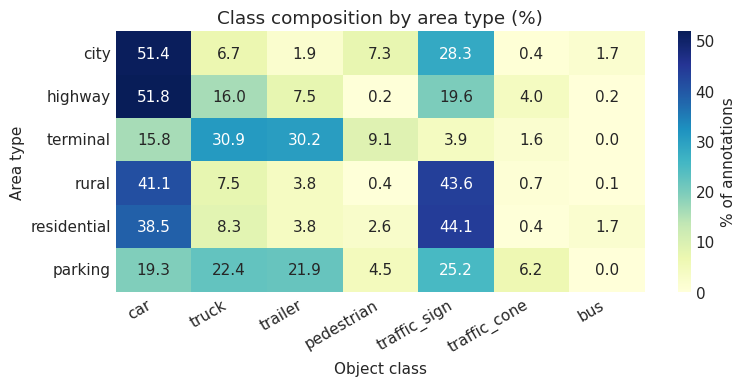

In [ ]:
plt.style.use("seaborn-v0_8-white")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11
})

fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0,
    cbar_kws={"label": "% of annotations"},
    annot_kws={"size": 11},
    ax=ax
)

ax.set_xlabel("Object class")
ax.set_ylabel("Area type")
ax.set_title("Class composition by area type (%)")

ax.set_xticklabels(main_classes, rotation=30, ha="right")
ax.set_yticklabels(areas, rotation=0)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/truckscenes_figures/fig_class_by_area.png", dpi=300, bbox_inches="tight")
plt.show()